In [12]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import geopandas 
import matplotlib.pyplot as plt

In [3]:
geolocator = Nominatim(user_agent="stelios-c GPS analysis")
alassa_location = geolocator.geocode("Alassa, Limassol District, Cyprus")
peyia_location = geolocator.geocode("Pegeia, Paphos District, Cyprus")

In [4]:
alassa_location

Location(Άλασσα, Alassa, Σύμπλεγμα Κοινοτήτων Κούρη & Ξυλορίκου, Επαρχία Λεμεσού, Κύπρος, 4540, Κύπρος - Kıbrıs, (34.7635333, 32.9274178, 0.0))

In [6]:
peyia_location

Location(Πέγεια, Δήμος Ακάμα, Επαρχία Πάφου, Κύπρος, Κύπρος - Kıbrıs, (34.8835052, 32.3803202, 0.0))

In [11]:
geodesic((alassa_location.latitude,alassa_location.longitude), 
         (peyia_location.latitude,peyia_location.longitude))

Distance(51.789830029040175)

in km by default

In [30]:
locations_gdf=geopandas.GeoDataFrame(geometry=geopandas.points_from_xy([alassa_location.longitude,peyia_location.longitude],
                                                         [alassa_location.latitude,peyia_location.latitude]),
                       crs="EPSG:4326")
#.set_index(['Alassa','Peyia'])

In [23]:
countries="https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
world = (geopandas
         .read_file(countries)
         .clip([31, 34, 35, 36])
         .dropna(axis='columns',how='all')
        )

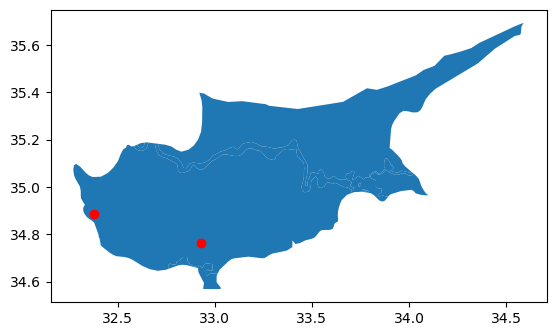

In [31]:
ax = world.plot()#column='colour',legend=True
locations_gdf.plot(ax=ax,color='red')
plt.show()